# 102. Rubin Schedule Viewer

<div style="max-width:300px; float: left; margin-right: 1em">

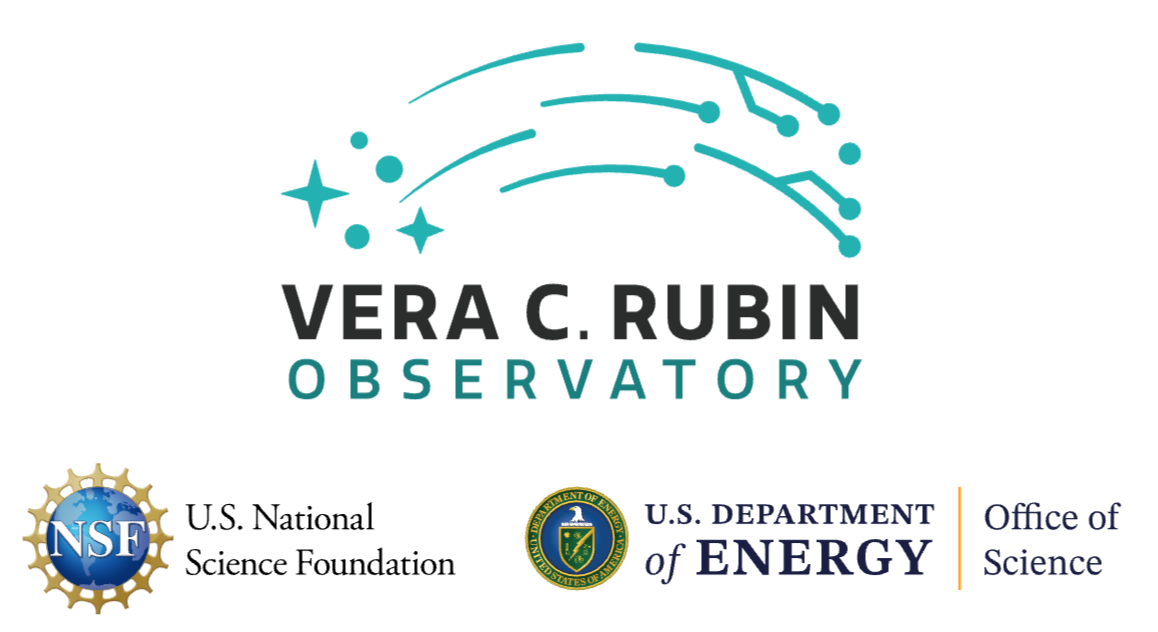

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Container Size: Large\
LSST Science Pipelines version: v29.2.0\
Last verified to run: 2026-02-18\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** How to programmatically query the Rubin Schedule Viewer.

**Rubin service:** The Rubin Schedule Viewer service runs at the USDF and is publicly available at 
<a href='https://usdf-rsp.slac.stanford.edu/obsloctap/static/viewer.html'> Rubin Schedule Viewer</a>.

**Packages:** `requests`

**Credit:** Developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial demonstrates how to query the **Rubin Schedule Viewer**, which is currently openly available via the US Data Facility at [https://usdf-rsp.slac.stanford.edu/obsloctap/static/viewer.html](https://usdf-rsp.slac.stanford.edu/obsloctap/static/viewer.html) (reload the page if it appears blank, and give it time to execute the default query).

The Rubin Schedule Viewer service publishes both the next scheduled visit and the predicted observing schedule for Rubin Observatory. 
It provides a user-friendly web interface as well as a programmatic web API, enabling the community to access up-to-date information 
for planning observations. The Rubin Schedule Viewer provides a **nominal survey schedule** at least **24 hours** in advance, 
followed by **updated schedules** published at least **2 hours** before each observing visit.


The design of the service is described in [DMTN-263](https://dmtn-263.lsst.io/).

### 1.1. ObsLocTAP - Observation Locator Table Access Protocol

The Rubin Schedule Viewer is built using the **IVOA Observation Locator Table Access Protocol (ObsLocTAP henceforth)** standard (<a href="https://www.ivoa.net/documents/ObsLocTAP/">Salgado et al.</a>) and incorporates information from an observatory's scheduler, including both **forecasted observations** and the **historical record** of completed visits.

ObsLocTAP specifies - in a standard format - services to retrieve information about planned, scheduled and performed observations of a given target (or coordinates) for a given astronomical observatory based on the existing ObsCore data model.
This standard does not describe the access to data obtained after the processing of the observational activity, as that is the goal of ObsCore (archived observations), although the discovery could be done in a similar way. 

ObsLocTAP defines a data model for scheduled observations and a method to run queries over compliant data, using several Virtual Observatory technologies. 

### 1.2. Key columns

The ObsLocTAP data model (table schema) for the scheduled observations is defined in the `ivoa.obsplan` table -- <a href="https://www.ivoa.net/documents/ObsLocTAP/20210609/PR-ObsLocTAP-1.0-20210609.pdf">Observation Locator 
Table Access Protocol Version 1.0</a>

The database contains 28 columns in total, and these are the key columns.

* `t_min` : The start time (MJD).
* `t_max` : The stop time (MJD).
* `s_ra` : The Right Ascension of the visit or planned observation (deg).
* `s_dec` : The Declination of the visit or planned observation (deg).
* `em_min` : The filter minimum wavelength (m).
* `em_max` : The filter maximum wavelength (m).
* `target_name` : The name of the astronomical object observed, if any.
* `tracking_type` : One of the following values: Sidereal, Solar-system-object-tracking, Fixed-az-el-transit.
* `priority` : The Priority level { 0, 1, 2}. 0 = in the target queue as the next visit
(meaning its execution is highly likely), 1 = in the 1 hour look-ahead summit queue (meaning likely),
2 = 24 hour pre-night simulation, meaning it is not in the summit queue and has a high degree of uncertainty. 
* `t_planning` : Time (MJD) when this observation has been added or modified into the planning log.
* `execution_status` : Execution status of the prediction: One of the following values: Planned, Scheduled, Unscheduled, Performed, Aborted.

Key columns that remained unpopulated as of the last update of this tutorial.

* `s_region` : Sky region covered by the data product (expressed in ICRS frame).
* `obs_id` : The observation ID from the Camera (currently the same as `target_name`).

These are also columns of interest, but are generally the same for most observations taken with LSSTCam.

* `t_plan_exptime` : The planned or scheduled exposure time (s).
* `t_exptime` : The total exposure time = `t_max - t_min` (s).
* `s_fov` : The diameter (bounds) of the covered region (deg).
* `s_resolution` : The spatial resolution of the data expressed as FWHM (arcsec/pixel).
* `facility_name` : Name of the facility used for this observation e.g Rubin Simonyi, AuxTel.
* `instrument_name` : Name of the instrument used for this observation e.g LSSTCam, LSSTComCam.

See  <a href="https://dmtn-263.lsst.io/">DMTN-263</a> for a description of all fields in the schema.

### 1.3. Import packages

Import the `requests` package to query the service and astropy's `Time` package to easily handle times and `bokeh` + `holoviews` for interactive visualization

In [1]:
import requests
import pandas as pd
import numpy as np
from astropy.time import Time

import holoviews as hv
from holoviews import opts
from bokeh.models import HoverTool
from bokeh.palettes import Turbo

import warnings

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
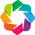

In [2]:
hv.extension("bokeh")
warnings.filterwarnings("ignore")

### 1.4. Define functions

Define a function to convert the `em_min` and `em_max` columns into the bandpass (filter) name.

In [3]:
def em_min_max_to_band(em_min, em_max):
    """
    Convert the wavelength minimum and maximum to band name.

    Parameters
    ----------
    em_min: float
        Wavelength minimum, in m.
    em_max: float
        Wavelength maximum, in m.

    Returns
    -------
    band: string
        Band (filter) name.
    """

    band = None
    band_dict = {'u': (2.95e-7, 4.05e-7), 'g': (4.00e-7, 5.55e-7),
                 'r': (5.50e-7, 6.92e-7), 'i': (6.90e-7, 8.20e-7),
                 'z': (8.15e-7, 9.25e-7), 'y': (9.20e-7, 11.1e-7)}
    for b in band_dict.keys():
        if em_min > band_dict[b][0] and em_max < band_dict[b][1]:
            band = b
    if band is None:
        print(em_min, em_max, ' no band found')

    return band

## 2. Rubin Schedule Viewer

The Rubin Schedule Viewer runs at the US Data Facility at SLAC. 

Define the ObsLocTAP URL of the service.

In [4]:
obsloctap_url = "https://usdf-rsp.slac.stanford.edu/obsloctap"

### 2.1. Graphical User Interface

The Rubin Schedule Viewer User Interface (UI) provides a convenient graphical user interface to query and explore the Rubin schedule of observations. 
It provides the facility to interactively query the historical and future schedule from a specified point in time (MJD or ISO) for a number of hours into the future.
It provides a filter by execution status, e.g. executed or scheduled, and a filter by `target_name`, e.g `low-dust`, `LMC_SMC`, `dusty_plane`.

The publicly accessible user interface is: [https://usdf-rsp.slac.stanford.edu/obsloctap/static/viewer.html](https://usdf-rsp.slac.stanford.edu/obsloctap/static/viewer.html) . 

Programmatically check the health of the static UI by executing the following cell, and assert that the static user interface service must be alive.

> **Warning:** If `RemoteDisconnect` errors are returned, it means the service is temporarily unstable or unavailable, and to try again later.

In [5]:
rubin_static_schedule_url = obsloctap_url + "/static/viewer.html"
response = requests.get(rubin_static_schedule_url)
assert response.status_code == 200, f"request failed with status {response.status_code}"
print(f"Rubin Schedule Viewer at {response.url} is alive.")

Rubin Schedule Viewer at https://usdf-rsp.slac.stanford.edu/obsloctap/static/viewer.html is alive.


### 2.2. Programmatic access

The service is also accessible programmatically, via ObsLocTAP, allowing users to extract metadata from the Schedule Viewer itself, including links such as the GitHub repository for the service code.
The Schedule Viewer does not require authentication, which is essential for publicly distributing the observing schedule.


Connect to the service file using `requests` package and assert that the service is alive.

In [6]:
response = requests.get(obsloctap_url)
assert response.status_code == 200, f"request failed with status {response.status_code}"
print(f"Rubin Schedule Viewer API at {response.url} is alive.")

Rubin Schedule Viewer API at https://usdf-rsp.slac.stanford.edu/obsloctap/ is alive.


### 2.3. Query the service header information

Retrieve the header metadata and print the keys.

In [7]:
headers = response.json()
assert headers is not None
meta_data = headers["metadata"]
print(meta_data.keys())

dict_keys(['name', 'version', 'description', 'repository_url', 'documentation_url'])


Print the service's description.

In [8]:
print(
    f'ObsLocTap service running at USDF for "{meta_data.get("description")}" \
with documentation at  url {meta_data.get("documentation_url")}.'
)

ObsLocTap service running at USDF for "Look at scheduler forecast and track what was observed" with documentation at  url https://obsloctap.lsst.io.


## 3. Retrieve the future schedule 

Query the Rubin Schedule Service to get the upcoming forecast for up to 24 hours in advance.

Define the schedule URL.

In [9]:
schedule_url = obsloctap_url + "/schedule"

Assert that the schedule forecast service is alive.

In [10]:
response = requests.get(schedule_url)
assert response.status_code == 200, f"request failed with status {response.status_code}"
print(f"Rubin Schedule Forecast  at {response.url} is alive.")

Rubin Schedule Forecast  at https://usdf-rsp.slac.stanford.edu/obsloctap/schedule is alive.


### 3.1. Retrieve the next 24 hours of schedule

As the default response of the schedule forecast is to return the next 24 hours of schedule, no additional parameters are needed.

Extract the list of upcoming visits as a json object and convert to a pandas dataframe,
then display the first five rows.

In [11]:
forward_24h_schedule = pd.DataFrame(response.json())
print(len(forward_24h_schedule))

1749


Print the first five rows.

In [12]:
forward_24h_schedule.head(5)

,t_planning,target_name,obs_id,obs_collection,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,...,pol_xel,facility_name,instrument_name,t_plan_exptime,category,priority,execution_status,tracking_type,rubin_rot_sky_pos,rubin_nexp
0,61101.402851,dusty_plane,dusty_plane,,198.973915,-76.914630,3.0,,0.2,61101.395907,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Scheduled,Sidereal,0.0,1
1,61101.402833,lowdust,lowdust,,299.714471,-24.633074,3.0,,0.2,61101.395889,...,0,Rubin:Simonyi,LSSTCam,15.0,Fixed,2,Not Observed,Sidereal,0.0,1
2,61101.402580,lowdust,lowdust,,299.743587,-21.662436,3.0,,0.2,61101.395635,...,0,Rubin:Simonyi,LSSTCam,15.0,Fixed,2,Not Observed,Sidereal,0.0,1
3,61101.402407,scp,scp,,217.241047,-80.475657,3.0,,0.2,61101.395462,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Scheduled,Sidereal,0.0,1
4,61101.401639,lowdust,lowdust,,302.586180,-29.524391,3.0,,0.2,61101.394695,...,0,Rubin:Simonyi,LSSTCam,15.0,Fixed,2,Scheduled,Sidereal,0.0,1


Note that the values in the "Execution Status" field  are all "Scheduled".

#### 3.1.1. Planned DDF observations

When alerts begin streaming in early 2026, template images will only exist for the DDFs, and thus alerts will only stream in the DDFs.

Print the number of planned observations per DDF in the next 24h, and in which filters the observations are planned.

First, add a column for the band (filter), converted from the `em_min` and `em_max` columns.

In [13]:
em_min = forward_24h_schedule['em_min'].values
em_max = forward_24h_schedule['em_max'].values
temp = []
for i in range(len(forward_24h_schedule)):
    temp.append(em_min_max_to_band(em_min[i], em_max[i]))
forward_24h_schedule['band'] = temp
del temp

Define the names of the DDF fields, in the format of the `target_name` column.
For each field, sum the number of planned observations and print the unique filters for those observations.

In [14]:
ddf_names = ['ddf_cosmos', 'ddf_ecdfs', 'ddf_elaiss1',
             'ddf_edfs_a', 'ddf_edfs_b', 'ddf_xmm_lss']

for ddf_name in ddf_names:
    temp = forward_24h_schedule.query("target_name.str.contains(@ddf_name)")
    band_list = "".join(str(value) for value in np.unique(temp['band']))
    print('%-12s %3i  bands: %-15s' % (ddf_name, len(temp), band_list))
    del temp, band_list

ddf_cosmos     0  bands:                
ddf_ecdfs      8  bands: gi             
ddf_elaiss1    0  bands:                
ddf_edfs_a     2  bands: gi             
ddf_edfs_b     2  bands: gi             
ddf_xmm_lss    0  bands:                


### 3.2. Retrieve the next 2 hours of schedule

Define a parameter to only retrieve the next 2 hours of schedule.

In [15]:
params = {"time": "2"}
response = requests.get(schedule_url, params=params)
expected_url = f"{schedule_url}?time={params['time']}"

assert (response.url == expected_url)
assert response.status_code == 200, f"request failed with status {response.status_code}"

Retrieve the forecasted schedule as a pandas dataframe and print the number of forecasted visits.

In [16]:
next_visits = pd.DataFrame(response.json())
print(
    f"There are {len(next_visits)} visits scheduled in the next {params["time"]} hours."
)

There are 0 visits scheduled in the next 2 hours.


Option to display the forecasted visits.

In [17]:
# next_visits

## 4. Retrieve a past planned schedule

A start date can also be specified that is in the past to retrieve the observations that were planned on previous nights. The date can be MJD or ISO format.

**Note that these are the observations that were *scheduled* for that night, they are not necessarily what was *observed*.**

Define the start date as October 1 2025, and the time range as 24 hours.

In [18]:
params = {"time": "24", "start": "2025-10-01"}

In [19]:
response = requests.get(schedule_url, params=params)
assert response.status_code == 200, f"request failed with status {response.status_code}"
print(response.url)

https://usdf-rsp.slac.stanford.edu/obsloctap/schedule?time=24&start=2025-10-01


In [20]:
next_visits_from_date = response.json()
print(
    f"There were {len(next_visits_from_date)} visits \
scheduled in the {params["time"]} hours from {params['start']}."
)

There were 1298 visits scheduled in the 24 hours from 2025-10-01.


Times can also be defined with the `astropy` package's `Time` module.

Define `past_time` as October 29 2025, and print it as a Modified Julian Date (MJD).

In [21]:
past_time = (Time("2025-10-29 22:00:00", format="iso", scale="utc")).mjd
print(past_time)

60977.916666666664


In [22]:
params = {"time": "24", "start": past_time}

In [23]:
response = requests.get(schedule_url, params=params)
assert response.status_code == 200, f"request failed with status {response.status_code}"
print(response.url)

https://usdf-rsp.slac.stanford.edu/obsloctap/schedule?time=24&start=60977.916666666664


In [24]:
next_visits_from_date_iso = pd.DataFrame(response.json())
print(
    f"There were {len(next_visits_from_date_iso)} visits scheduled in the \
{params["time"]} hours from {Time(params['start'], format='mjd').iso}."
)

There were 712 visits scheduled in the 24 hours from 2025-10-29 22:00:00.000.


Display 5 of the visits of the retrieved table.

In [25]:
next_visits_from_date_iso.head(5)

,t_planning,target_name,obs_id,obs_collection,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,...,pol_xel,facility_name,instrument_name,t_plan_exptime,category,priority,execution_status,tracking_type,rubin_rot_sky_pos,rubin_nexp
0,60978.369741,,2025082500179,BLOCK-T278_v2|,33.707931,-42.486653,3.0,,0.2,60913.158328,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Performed,Sidereal,26.530376,1
1,60978.369285,,2025082500179,BLOCK-T278_v2|,35.876726,-39.788507,3.0,,0.2,60913.158328,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Performed,Sidereal,26.530376,1
2,60978.368845,,2025082500179,BLOCK-T278_v2|,39.465146,-39.939261,3.0,,0.2,60913.158328,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Performed,Sidereal,26.530376,1
3,60978.368393,,2025082500179,BLOCK-T278_v2|,37.844238,-37.054514,3.0,,0.2,60913.158328,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Performed,Sidereal,26.530376,1
4,60978.367953,,2025082500179,BLOCK-T278_v2|,41.304876,-37.152617,3.0,,0.2,60913.158328,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,2,Performed,Sidereal,26.530376,1


### 4.1. Execution status

Note the values in the "Execution Status" field for the night of Oct 29 2025: they are all "Not Observed".

In [26]:
next_visits_from_date_iso["execution_status"].unique().tolist()

['Performed', 'Not Observed']

During October 2025, the LSST has not started and testing at the summit is highly variable, and there was a very high probability that the observations scheduled were not executed.

This will change as the Rubin Observatory moves into steady state LSST survey operations.

## 5. Analyze a predicted schedule

Use the 24 hours of schedule prediction for Oct 29 2025, which was retrieved in Section 4.

### 5.1. Inter-visit time gaps

Extract the planned observation times and calculate the differences between successive values, in seconds.

In [27]:
t_planning = next_visits_from_date_iso["t_planning"].values
obs_visit_gap = []
for i in range(len(t_planning) - 1):
    diff = abs(t_planning[i] - t_planning[i + 1]) * 60 * 60 * 24
    if np.isnan(diff):
        continue
    obs_visit_gap.append(diff)
print(f"Number of differences: {len(obs_visit_gap)}")

Number of differences: 711


Print the minimum, maximum, and median visit gap time.

In [28]:
print(f"Min gap: {np.min(obs_visit_gap): .2f}")
print(f"Max gap: {np.max(obs_visit_gap): .2f}")
print(f"Mean gap: {np.mean(obs_visit_gap): .2f}")

Min gap:  34.07
Max gap:  326.45
Mean gap:  42.20


Create the hover tool.

In [29]:
hover = HoverTool(
    tooltips=[("Gap Range", "@left{0.00} - @right{0.00}"), ("Count", "@top")]
)

Create the histogram.

In [30]:
histogram = hv.Histogram(
    np.histogram(obs_visit_gap, bins=50), kdims="Time Gap", vdims="Counts"
).opts(
    title="Successive planned visit gaps for Oct 29 2025",
    xlabel="Gap (seconds)",
    ylabel="log(Count)",
    width=600,
    height=400,
    logy=True,
    line_color="steelblue",
    fill_color="lightblue",
    line_width=1,
    show_grid=True,
    tools=["hover", "pan", "wheel_zoom", "box_zoom", "reset"],
)
histogram

:Histogram   [Time Gap]   (Counts)

> **Figure 1:** The distribution of the log number of planned observations with a given time gap between it and the next observation.

### 5.2. Planned time by target field

Plot curves of the scheduled observation times for each target field that was planned to be observed the night of Oct 29 2025.

Get unique target names.

In [31]:
unique_targets = next_visits_from_date_iso["target_name"].unique()
target_to_y = {target: i for i, target in enumerate(unique_targets)}

Make a copy of the retrieved database of planned visits, and add the y-axis name to it.

In [32]:
df_plot = next_visits_from_date_iso.copy()
df_plot["y"] = df_plot["target_name"].map(target_to_y)

Create a color map from a palette with 30 colors.

In [33]:
np.random.seed(42)
palette = list(np.random.choice(Turbo[256], len(unique_targets), replace=False))
colors = {target: palette[i % len(palette)] for i, target in enumerate(unique_targets)}

Create the scatter plot for each target name, and overlay them.

In [34]:
scatter_plots = []
for target in unique_targets:
    target_data = df_plot[df_plot["target_name"] == target]
    scatter = hv.Scatter(
        target_data, kdims=["t_planning"], vdims=["y", "target_name"], label=target
    )
    scatter.opts(opts.Scatter(color=colors[target]))
    scatter_plots.append(scatter)

plot = hv.Overlay(scatter_plots)

Configure the hover tool.

In [35]:
hover = HoverTool(
    tooltips=[
        ("target_name", "@{target_name}"),
        ("t_planning", "@{t_planning}{0.000000}"),
    ]
)

Create the y-axis tick labels, one for each target name.

In [36]:
y_ticks = [(i, target) for target, i in target_to_y.items()]

Set all the other plot options and show the plot.

In [37]:
plot = plot.opts(
    opts.Scatter(
        width=600,
        height=400,
        tools=[hover, "pan", "wheel_zoom", "box_zoom", "reset", "save"],
        xlabel="Scheduled Observation Time (MJD)",
        ylabel="Target Name",
        title="Planned observations by target for Oct 29 2025",
        size=8,
        alpha=0.7,
        legend_position="right",
        legend_offset=(10, 0),
        yticks=y_ticks,
        show_legend=False,
    )
)
plot

:Overlay
   .Scatter.I                                               :Scatter   [t_planning]   (y,target_name)
   .Scatter.Lowdust_comma_ddf_edfs_b                        :Scatter   [t_planning]   (y,target_name)
   .Scatter.Lowdust_comma_ddf_edfs_a                        :Scatter   [t_planning]   (y,target_name)
   .Scatter.LMC_SMC_comma_lowdust                           :Scatter   [t_planning]   (y,target_name)
   .Scatter.Scp                                             :Scatter   [t_planning]   (y,target_name)
   .Scatter.Scp_comma_lowdust                               :Scatter   [t_planning]   (y,target_name)
   .Scatter.LMC_SMC                                         :Scatter   [t_planning]   (y,target_name)
   .Scatter.LMC_SMC_comma_scp                               :Scatter   [t_planning]   (y,target_name)
   .Scatter.Ddf_xmm_lss_comma_lowdust                       :Scatter   [t_planning]   (y,target_name)
   .Scatter.Scp_comma_euclid_overlap                        :Scatter   [t_planning]   (y,target_name)
   .Scatter.LMC_SMC_comma_euclid_overlap                    :Scatter   [t_planning]   (y,target_name)
   .Scatter.Ddf_elaiss1_comma_GW_case_large_1_comma_lowdust :Scatter   [t_planning]   (y,target_name)
   .Scatter.Euclid_overlap                                  :Scatter   [t_planning]   (y,target_name)
   .Scatter.Lowdust_comma_euclid_overlap                    :Scatter   [t_planning]   (y,target_name)

> **Figure 2:** The time of the planned observation (x-axis) for each of the planned target fields (y-axis), for the night of Oct 29 2025.

## 6. Exercises for the learner

1. Repeat the analysis in Section 5, but for the next 24 hours of planned observations.

> **Warning:** If "the next 24 hours" includes an inter-night gap (i.e., daytime), the inter-visit time gap distribution in Figure 1 will have two visits separated by 8 hours or more, and the x-axis values will extend to $\sim28000$ seconds or more. Figure 2 will also show a daytime gap with no planned visits.